# Desafio 3: Um problema de Machine Learning Classico

#### Objetivo:
Neste desafio vocês irão aplicar, na prática, os conceitos fundamentais de um projeto de Machine Learning supervisionado. O objetivo é desenvolver um modelo capaz de prever quais passageiros sobreviveram ao naufrágio do Titanic, utilizando o conjunto de dados disponibilizado pelo Kaggle. Mais importante do que obter uma pontuação elevada na competição é compreender e executar todas as etapas do ciclo de desenvolvimento de um projeto de Machine Learning, desde a exploração dos dados até a submissão do resultado. 

#### Contexto: 
O desafio **Titanic – Machine Learning from Disaster**, disponibilizado pelo Kaggle, é uma das competições mais conhecidas para introdução ao Machine Learning. Seu objetivo é construir um modelo capaz de prever se um passageiro sobreviveu ou não ao desastre do Titanic, utilizando informações como idade, sexo, classe da passagem, número de familiares, tarifa paga, entre outras. 

#### Requisitos mínimos:
* Estar implementada em um único notebook Jupyter;
* Realizar a leitura da base de treinamento disponibilizada pelo Kaggle;
* Executar uma análise exploratória dos dados (EDA).
* Tratar valores ausentes, inconsistências e realizar as transformações necessárias para o treinamento do modelo;
* Treinar pelo menos um modelo de Machine Learning supervisionado para classificação;
* Gerar as previsões para a base de teste;
* Produzir o arquivo de submissão no formato exigido pelo Kaggle;
* Submeter o resultado à competição e obter uma pontuação válida

#### Recomendação de boas praticas
* Documentar as principais etapas do notebook;
* Explicar as decisões adotadas durante o tratamento dos dados;
* Comparar dois ou mais algoritmos de Machine Learning;
* Avaliar a importância das variáveis utilizadas pelo modelo;
* Organizar o código de forma clara e comentada;
* Garantir a reprodutibilidade dos resultados (por exemplo, utilizando random_state);


#### Parte 1 - Setup e Leitura dos Dados
#### [Parte 2 - Análise Exploratória (EDA) e Pré-processamento](#parte-2-eda)
#### [Parte 3 - Modelagem de Machine Learning](#parte-3-ML)
#### Parte 4 - Previsões e Submissão 

## 1. Setup e Leitura dos Dados

In [1]:
import numpy as np
import pandas as pd

from setup_notebook import setup_path
setup_path()
from src.functions import *

from unittest.mock import patch

import warnings

warnings.filterwarnings("ignore")

In [2]:
# 2-Dataload & Pré-visualização dos Dados
dfo = pd.read_csv("/home/akel/PycharmProjects/Kaggle/Titanic/data/raw/train.csv")
df=dfo.drop(columns='PassengerId')

<a id="parte-2-eda"></a>
## 2. Análise Exploratória (EDA) e Pré-processamento

In [3]:
inital_describe(df)

📊 ANÁLISE EXPLORATÓRIA DO DATAFRAME

📈 DIMENSÕES DO DATASET:
   • 891 linhas
   • 11 colunas
   • Total de células: 9801

🔧 TIPOS DE DADOS:
   • object: 5 colunas
   • int64: 4 colunas
   • float64: 2 colunas

📋 DETALHAMENTO DOS TIPOS POR COLUNA:
             Tipo
Survived    int64
Pclass      int64
Name       object
Sex        object
Age       float64
SibSp       int64
Parch       int64
Ticket     object
Fare      float64
Cabin      object
Embarked   object

🔍 VERIFICAÇÃO DE QUALIDADE DOS DADOS

📝 REGISTROS DUPLICADOS:
   • Total: 0
   • Percentual: 0.00%

❌ VALORES NULOS:
   • Total: 866
   • Percentual: 8.84%

📊 COLUNAS COM VALORES NULOS:
   • Age: 177 nulos (19.87%)
   • Cabin: 687 nulos (77.10%)
   • Embarked: 2 nulos (0.22%)

🔎 ANÁLISE DAS COLUNAS CATEGÓRICAS

NAME
Quantidade de valores únicos: 891

SEX
Quantidade de valores únicos: 2
Valores: ['male' 'female']

TICKET
Quantidade de valores únicos: 681

CABIN
Quantidade de valores únicos: 147

EMBARKED
Quantidade de valores único

,count,mean,std,min,25%,50%,75%,max
Survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
Pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
Age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
SibSp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
Parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
Fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292



✅ ANÁLISE CONCLUÍDA


### 2.1 Pré-processamento de Dados

Com base nos achados da análise exploratória, foram aplicadas as seguintes transformações no conjunto de dados:

**A. `HasCabin` e `Deck`**

* **`HasCabin`**: Cria uma variável binária ($1$ para presença de cabine, $0$ para ausência) a partir de `Cabin`.
* **`Deck`**: Extrai a letra inicial do código da cabine. Valores nulos ou associados ao conves raro `'T'` foram agrupados sob a categoria `'U'` (*Unknown*). A coluna original `Cabin` é removida.

**B. `Embarked`**

* Imputação de valores ausentes pela **moda**, devido ao baixo volume de dados faltantes.

**C. Imputação Hierárquica de Idade (`Age`)**

* Criação de uma variável temporária de idade (`Age2`), preenchendo os nulos de forma regressiva através da mediana agrupada por `Sex`, `Pclass` e `HasCabin`:
1. Agrupamento por `['Sex', 'Pclass', 'HasCabin']`.
2. Agrupamento por `['Sex', 'Pclass']`.
3. Agrupamento por `['Sex']`.
4. Mediana geral da base (caso ainda restem nulos).


* Ao final, a coluna original `Age` é substituída pelo resultado preenchido.

**D. `Age_Group`**

* Categorização da idade em faixas etárias: *Criança (<12)*, *Adolescente (12-18)*, *Adulto Jovem (19-30)*, *Adulto (31-50)* e *Idoso (>50)*.

**E. `Fare`**

* Imputação dos valores ausentes da tarifa pela **mediana** geral da coluna.

**F. `FamilySize`**

* Cálculo do tamanho total da família somando os parentes a bordo (`SibSp` + `Parch`) mais o próprio passageiro ($+1$).

**G. `Title`**

* Extração do título do passageiro a partir de `Name`. Títulos equivalentes foram padronizados (`Mlle`/`Ms` $\rightarrow$ `Miss`, `Mme` $\rightarrow$ `Mrs`) e os títulos raros (fora do grupo `Mr`, `Miss`, `Mrs`, `Master`) foram agrupados na categoria `'Rare'`.

**H. Remoção de Colunas Irrelevantes**

* Exclusão das variáveis `Name` e `Ticket`, por não serem utilizadas diretamente nas etapas subsequentes.

---

#### Resumo do pré-processamento

* **Aproveitamento de dados incompletos:** Criação de **HasCabin** e **Deck**, além da remoção de `Cabin`.
* **Tratamento rigoroso de nulos:** Imputação hierárquica e condicional para **Age** (agrupada por sexo, classe e cabine), além de preenchimento por moda (**Embarked**) e mediana (**Fare**).
* **Engenharia de recursos (Feature Engineering):** Construção de variáveis explicativas como **Age_Group**, **FamilySize** e **Title** (com aglutinação de títulos raros).
* **Limpeza estrutural:** Exclusão de identificadores de texto sem valor preditivo direto (`Name` e `Ticket`).


In [4]:
# A. HasCabin & Deck
if 'Cabin' in df.columns:
    # Variável HasCabin
    df['HasCabin'] = df['Cabin'].notnull().astype(int)
    # Variável Deck
    df['Deck'] = df['Cabin'].apply(
        lambda x: 'U' if pd.isnull(x) or str(x)[0] == 'T' else str(x)[0]
    )
    df.drop(columns='Cabin', inplace=True)

# B. preenchimento com a moda
if 'Embarked' in df.columns:
    df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# C. Variable Age imputed is Age2
if 'Age' in df.columns:
    coll_age = ['Sex', 'Pclass', 'HasCabin']
    df['Age2'] = df['Age'].copy()
    for i in range(len(coll_age)):
        if df['Age2'].isnull().sum() > 0:
            df['Age2'] = df['Age2'].fillna(
                df.groupby(coll_age[0:3 - i])['Age'].transform('median')
            )
    df['Age2'] = df['Age2'].fillna(df['Age'].median())
    df.drop(columns='Age', inplace=True)
df.rename(columns={'Age2': 'Age'}, inplace=True)

# D-Categorizando grupos por idades.

df['Age_Group'] = pd.cut(
    df['Age'],
    bins=[0, 12, 18, 30, 50, 80],
    labels=[
        'Criança (<12)',
        'Adolescente (12-18)',
        'Adulto Jovem (19-30)',
        'Adulto (31-50)',
        'Idoso (>50)'
    ]
)

# E. Variable Fare imputed by median
if 'Fare' in df.columns:
    df['Fare'] = df['Fare'].fillna(df['Fare'].median())

# F. Variable FamilySize 
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

# G. Extração e agrupamento de Title
if 'Name' in df.columns:
    df['Title'] = df['Name'].str.split(', ').str[1].str.split('.', n=1).str[0]
    df['Title'] = df['Title'].replace({"Mlle": "Miss", "Ms": "Miss"})
    df['Title'] = df['Title'].replace("Mme", "Mrs")
    common_titles = ['Mr', 'Miss', 'Mrs', 'Master']
    df['Title'] = df['Title'].apply(lambda x: x if x in common_titles else 'Rare')

# H. Remoção de colunas não utilizadas nesta análise
drop_cols = [c for c in ['Name', 'Ticket'] if c in df.columns]
df.drop(columns=drop_cols, inplace=True)

### 2.2 Pré-visualização dos Dados 

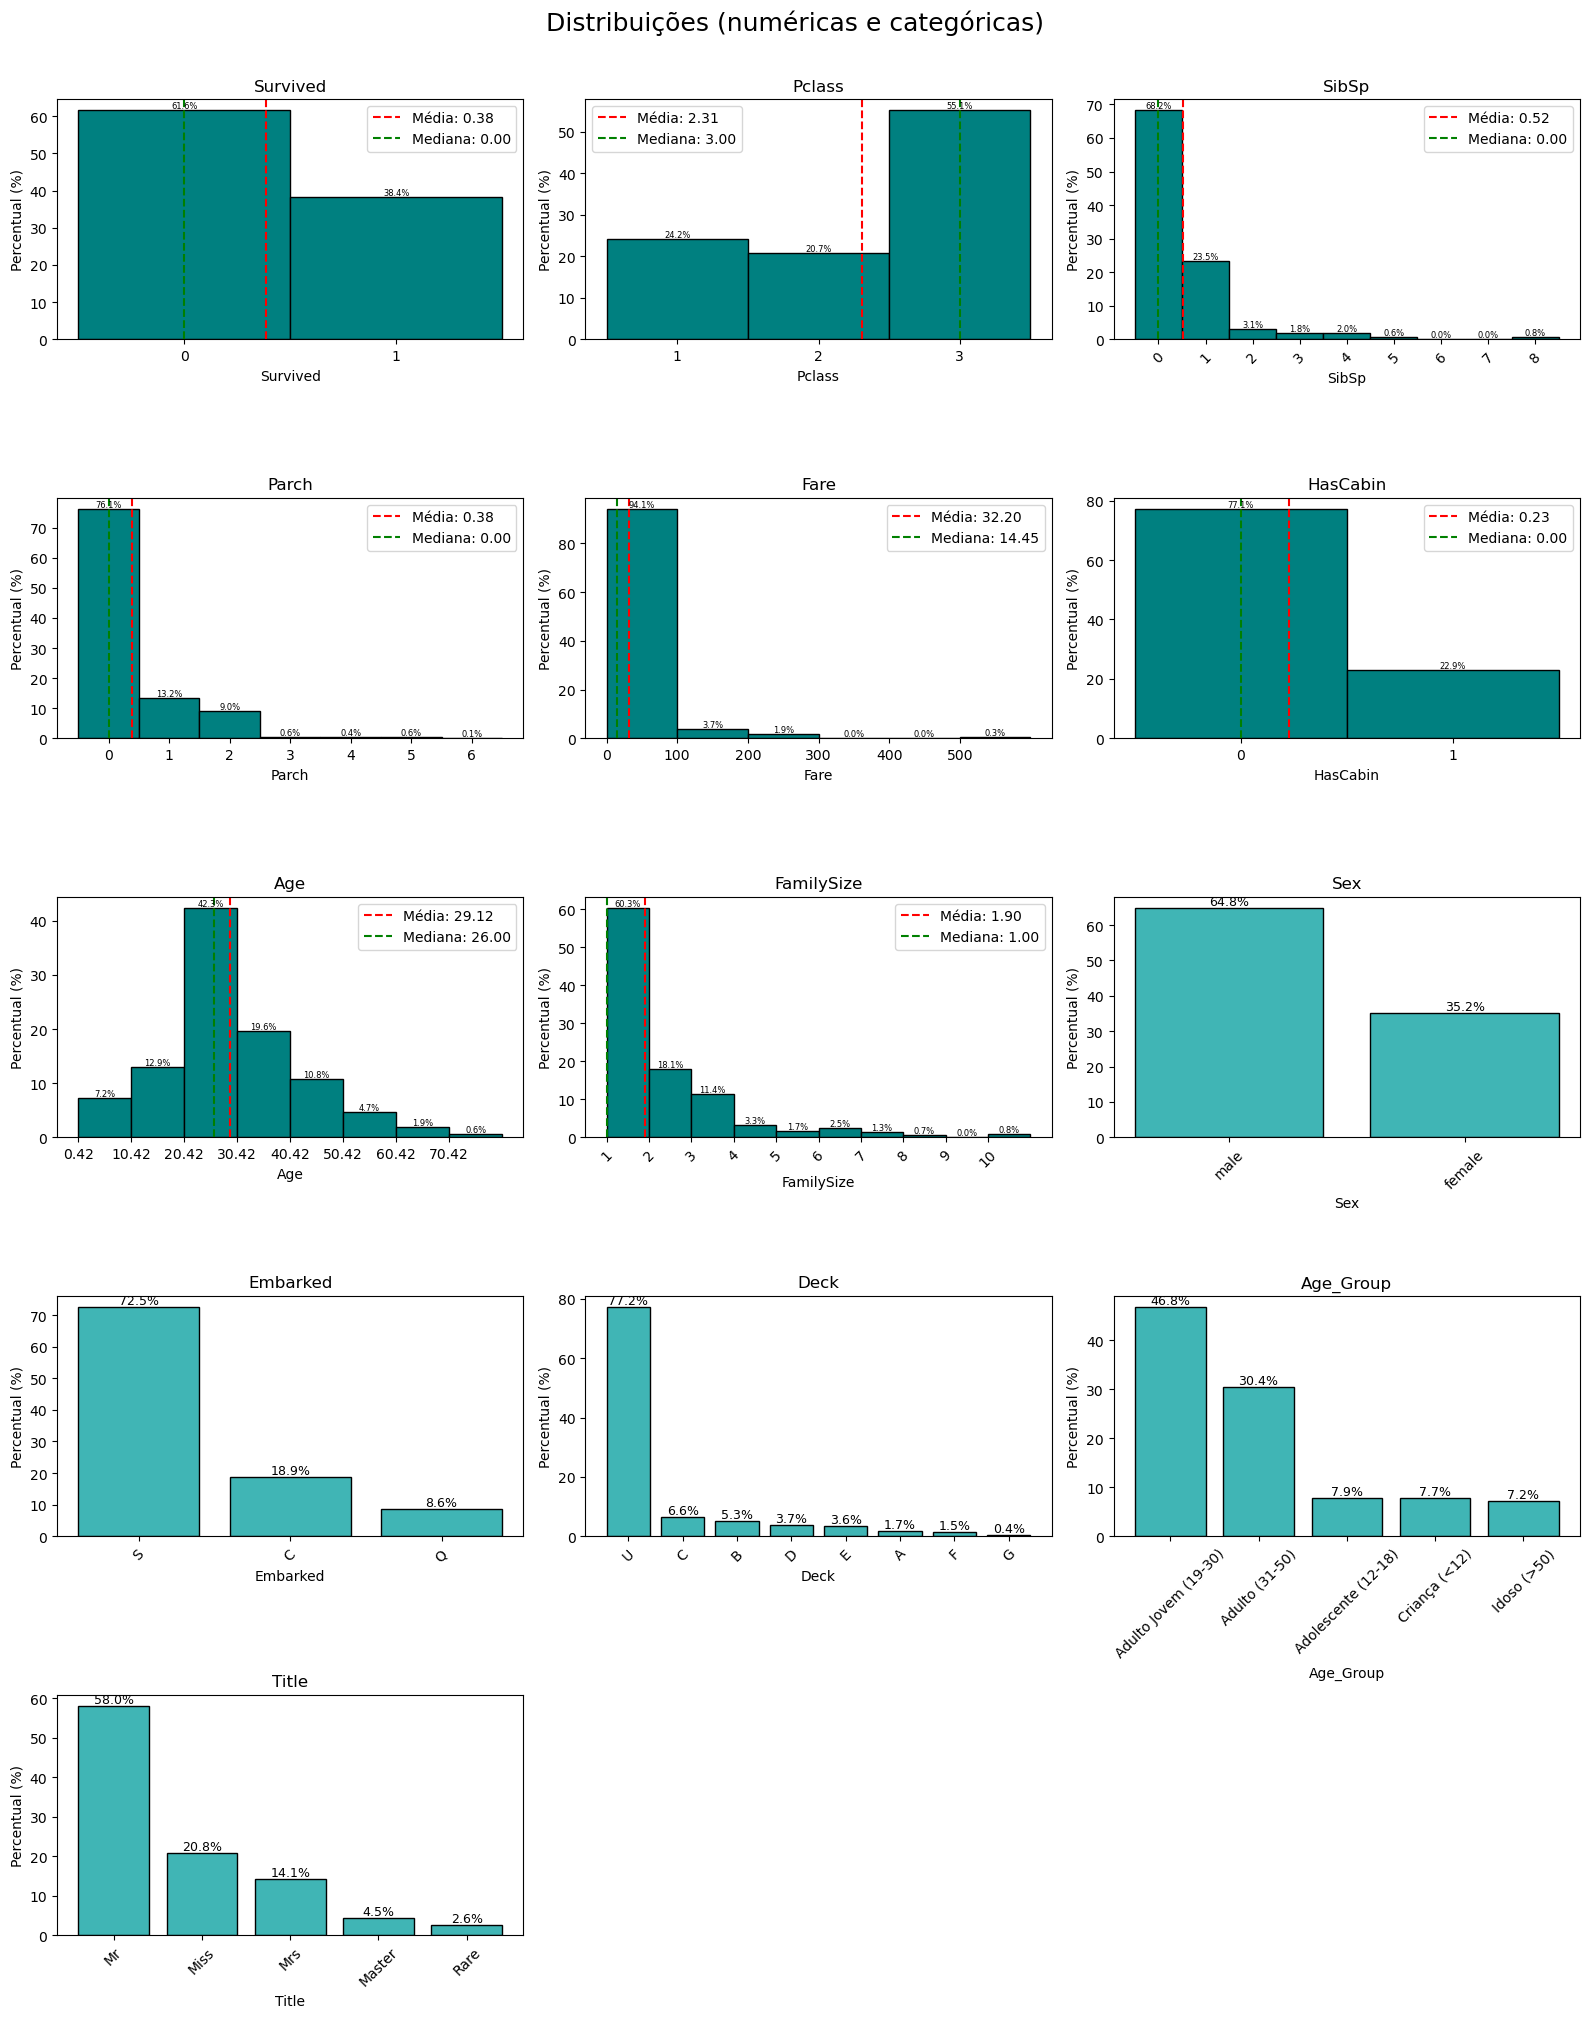

In [5]:
out=mult_plt2(df,ncols=3,max_bins=10,figsize=(16,20))

**Perfil sociodemográfico e familiar**

A maioria dos passageiros era do sexo masculino (\~64%), adulta jovem (19–30 anos: \~47%) e pertencia à 3ª classe (\~55%), com títulos predominantes de "Mr" (\~58%). Em termos familiares, grande parte viajava sem parentes a bordo (SibSp=0: \~68%; Parch=0: \~76%), e o tamanho familiar mais comum foi de 1,5 pessoa (\~60%). A maioria não possuía cabine registrada (\~77%) ou estava no deck desconhecido "U" (\~77%), e as tarifas pagas foram majoritariamente baixas (até 50 unidades: \~94%).

**Sobrevivência, embarque e distribuição etária**

A taxa de sobrevivência geral foi de apenas \~38%, contra 61% de não sobreviventes. O porto de embarque mais frequente foi Southampton (S), com \~72% dos passageiros. Quanto à idade, além dos adultos jovens, os demais grupos etários incluíam adultos (31–50 anos: \~30), adolescentes (\~8%), crianças (\~8%) e idosos (\~7%). Os títulos femininos ("Miss" e "Mrs") somaram cerca de \~35%, enquanto títulos raros representaram apenas \~2,5% da amostra.

### 2.3 Análise de Sobrevivência por Variável
Com base nas estatísticas geradas, abaixo estão os principais achados para cada grupo de dados, destacando a proporção de sobrevivência (onde $1$ representa sobreviveu e $0$ não sobreviveu).

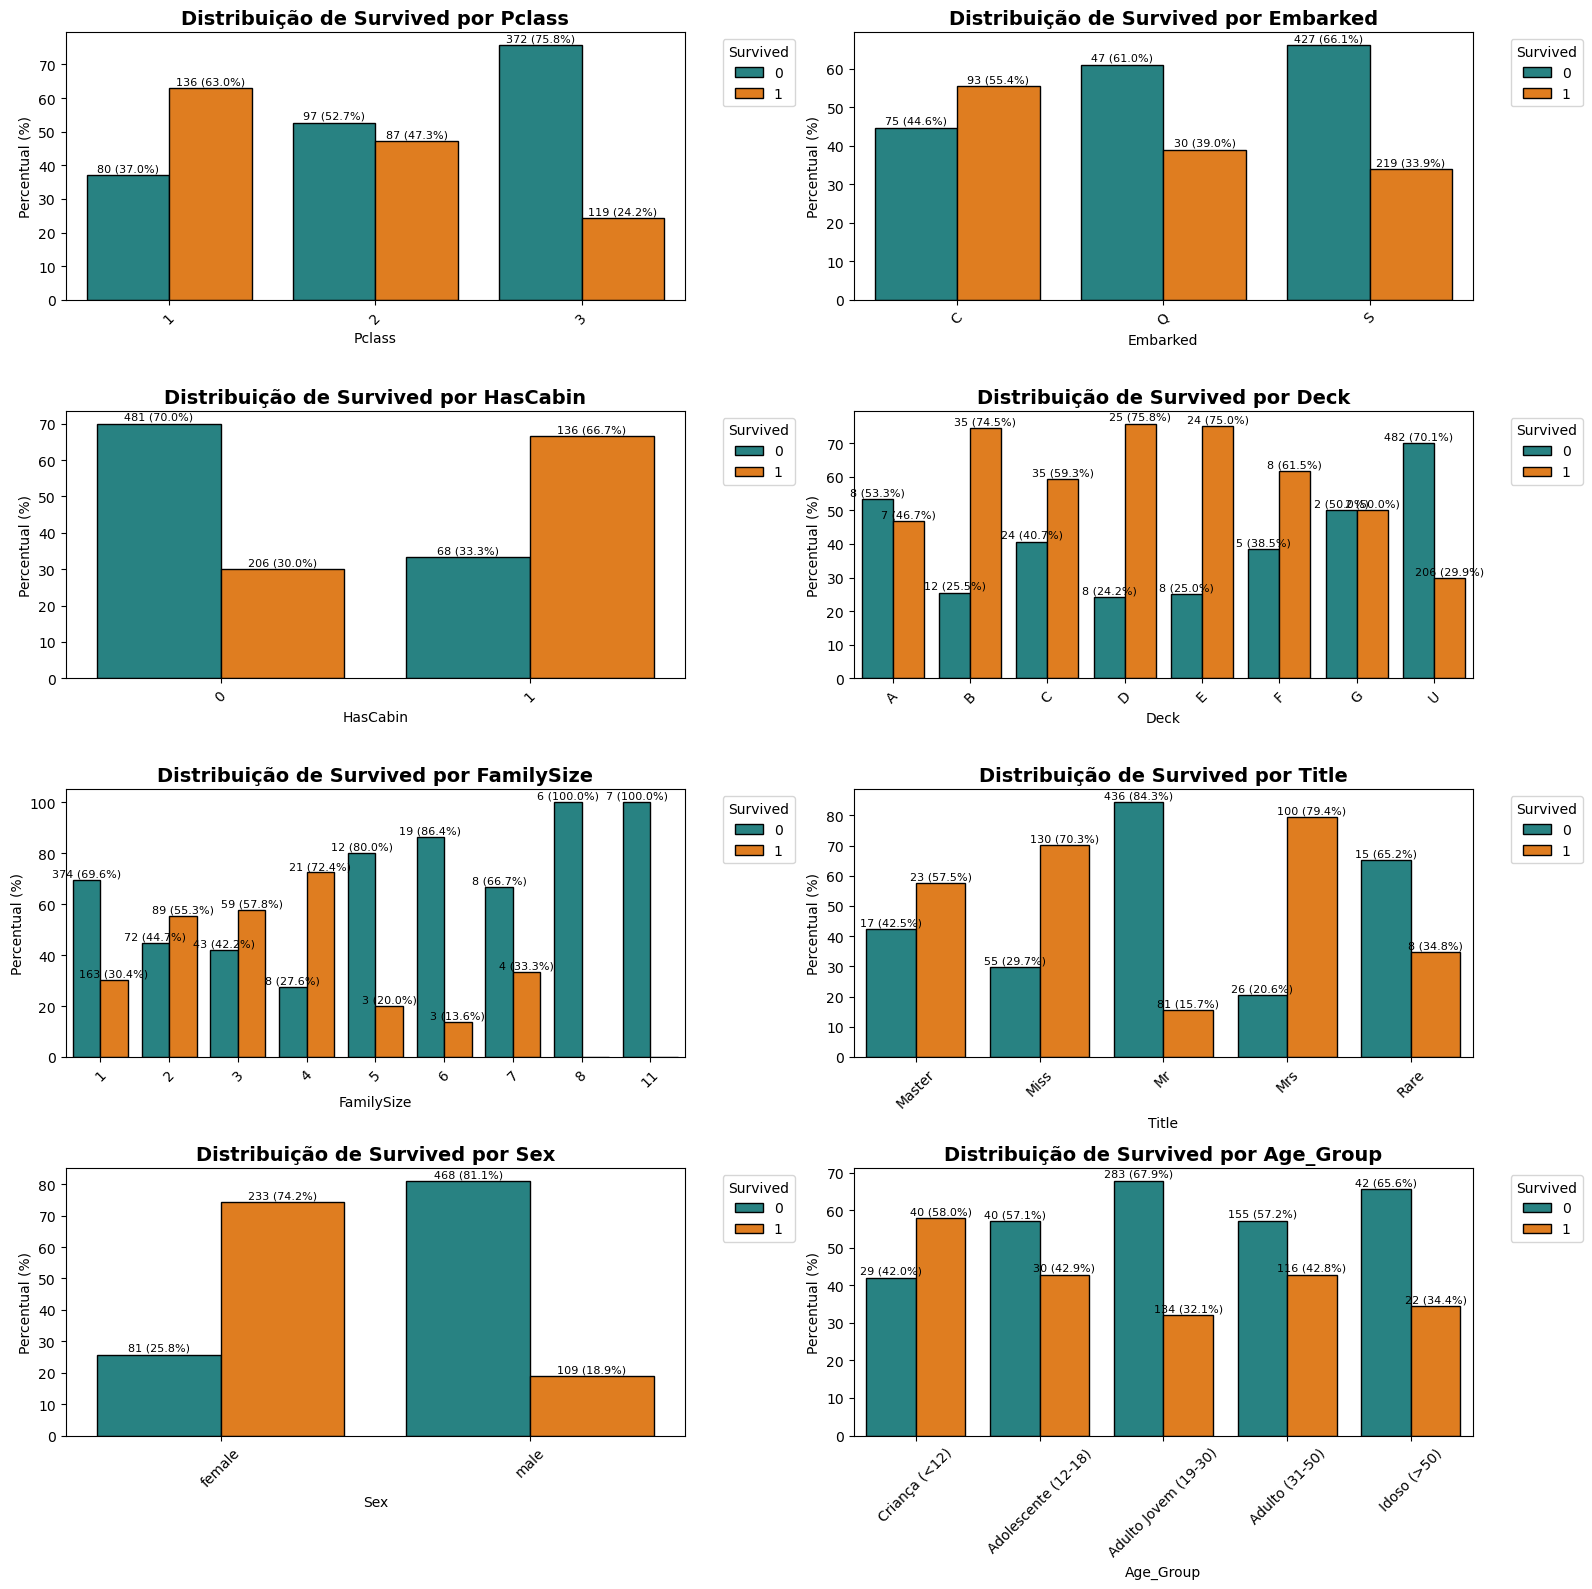

In [6]:
# 1. Cria a figura do grid 2x2
fig, axes = plt.subplots(4, 2, figsize=(16, 16))

# Mapeia cada subplot para a coluna do seu DataFrame
stat = {}
variaveis = [
    ("Pclass", axes[0, 0]),
    ("Embarked", axes[0, 1]),
    ("HasCabin", axes[1, 0]),
    ("Deck", axes[1, 1]),
    ("FamilySize", axes[2, 0]),
    ("Title", axes[2, 1]),
    ("Sex", axes[3, 0]),
    ("Age_Group", axes[3, 1])]

# 2. Desativa o plt.show e plt.figure temporariamente
with (
    patch("matplotlib.pyplot.show"),
    patch("matplotlib.pyplot.figure"),
    patch("matplotlib.pyplot.tight_layout"),
):
    for col, ax in variaveis:
        # Define o eixo atual do Matplotlib
        plt.sca(ax)
        

        # Chama a sua função original sem modificá-la
        stat[col]=bar_bar_cat(df, col, "Survived", figsize=(10, 5))

# 3. Ajusta o layout final do grid e exibe
plt.tight_layout()
plt.show()


**A. Classe do Passageiro (`Pclass`)**

* Existe uma correlação direta entre classe social e sobrevivência. Passageiros da 1ª classe tiveram a maior taxa de sobrevivência  (\~63%), seguidos pela 2ª classe (~47%).
* A 3ª classe foi a mais impactada, com a grande maioria não sobrevivendo (apenas ~24% de sobrevivência em um grupo de 491 pessoas).

**B. Porto de Embarque (`Embarked`)**

* Passageiros que embarcaram em Cherbourg (`C`) tiveram a maior taxa de sobrevivência (~55%).
* Aqueles que embarcaram em Southampton (`S`) e Queenstown (`Q`) registraram taxas significativamente menores (~34% e ~39%, respectivamente).

**C. Presença de Cabine (`HasCabin`)**

* Ter uma cabine registrada foi um forte indicador positivo: ~67% dos passageiros com cabine sobreviveram.
* Em contraste, aqueles sem registro de cabine (`0`) tiveram apenas ~30% de chance de sobrevivência.

**D. Convés (`Deck`)**

* Os conveses **B, D e E** apresentaram as maiores taxas de sobrevivência, todas na faixa de 74% a 76%.
* O grupo `U` (Desconhecido/Sem cabine) teve a menor taxa, com quase 70% de mortalidade, reforçando o achado da variável `HasCabin`.

**E. Tamanho da Família (`FamilySize`)**

* Viajar sozinho (tamanho 1) resultou em uma baixa taxa de sobrevivência (~30%).
* Famílias pequenas a médias (2 a 4 pessoas) apresentaram as melhores chances, variando de 55% a 72% de sobrevivência (o pico de sucesso foi em famílias de 4 pessoas).
* Famílias grandes (5 ou mais pessoas) sofreram quedas drásticas na sobrevivência, chegando a 0% para famílias de 8 e 11 membros.

**F. Título (`Title`)**

* Títulos femininos dominaram as taxas de sobrevivência: `Mrs` (~79%) e `Miss` (~70%).
* O título `Master` (meninos) teve **~58%** de sobrevivência.
* O título `Mr` (homens adultos) registrou a pior taxa, com impressionantes 84% de não sobreviventes.

**G. Sexo (`Sex`)**

* A diferença de gênero é a mais gritante do conjunto de dados: mulheres tiveram ~74% de chance de sobrevivência, enquanto homens tiveram apenas ~19%.

**H. Faixa Etária (`Age_Group`)**

* Crianças (<12 anos) foram o único grupo etário com mais sobreviventes do que vítimas (~58% de sobrevivência).
* Adultos Jovens (19-30 anos) e Idosos (>50 anos) registraram as maiores taxas de mortalidade em seus grupos, com apenas ~32% e ~34% de sobrevivência, respectivamente.

### 2.4. Análise de Correlação de Spearman

A matriz de correlação de Spearman confirma de forma quantitativa as tendências observadas na análise categórica e revela como as variáveis interagem entre si:

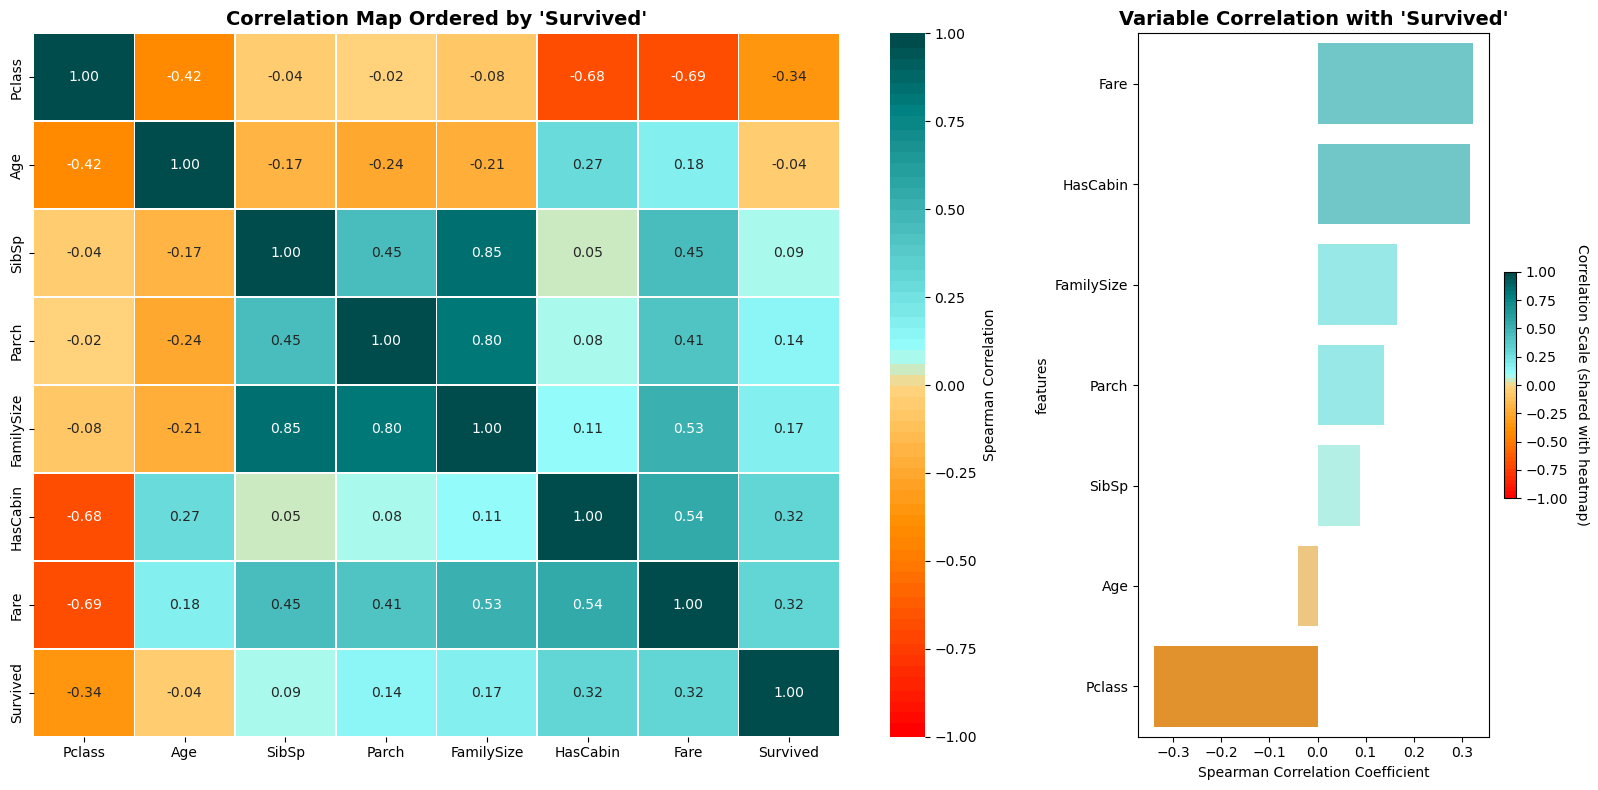

In [7]:
#Correlação
corr_vars = ['Survived','Pclass','Fare','Age','FamilySize','Title','SibSp','Parch','HasCabin']
corr,corr_tag=correlation_bar(df[corr_vars],'Survived',metodo='spearman')


**Correlações com a Sobrevivência (`Survived`):**

* **Status Socioeconômico:** As variáveis `Fare` (0.32) e `HasCabin` (0.32) apresentam correlação positiva moderada com a sobrevivência, enquanto `Pclass` (-0.34) apresenta uma correlação negativa moderada. Isso quantifica a regra de que quanto maior o poder aquisitivo (maior tarifa, presença de cabine, menor o número numérico da classe), maiores as chances de sobreviver.
* **Tamanho da Família:** `FamilySize` (0.17) e `Parch` (0.14) mostram correlações positivas fracas com a sobrevivência. Isso reflete o benefício de viajar acompanhado, embora a força da correlação seja diluída pelo fato de famílias excessivamente grandes terem altas taxas de mortalidade.
* **Idade:** A variável `Age` (-0.04) quase não apresenta correlação linear monotônica com a sobrevivência. Isso ocorre porque o impacto da idade não é uma linha reta (crianças sobreviveram muito, adultos em idade produtiva morreram mais, e idosos também morreram mais), o que explica a correlação próxima a zero.

**Correlações entre as Variáveis Preditoras (Colinearidade):**

* Existe uma fortíssima interdependência entre `Pclass`, `Fare` (-0.69) e `HasCabin` (-0.68). Isso significa que essas três variáveis estão contando essencialmente a mesma história: a 1ª classe paga tarifas mais altas e tem acesso a cabines.
* Naturalmente, `FamilySize` possui uma correlação muito forte com `SibSp` (0.85) e `Parch` (0.80), validando a construção correta da variável derivada.

### 2.6. Principais Insights e Conclusões (Resumo Geral)

A análise revela que a sobrevivência no Titanic não foi um evento aleatório, mas sim fortemente governada por regras sociais da época e condições logísticas:

1. **A Regra "Mulheres e Crianças Primeiro" prevaleceu:** A discrepância gigantesca nas taxas de sobrevivência entre os sexos (74% mulheres vs 19% homens) e títulos (`Mrs`/`Miss`/`Master` vs `Mr`), além do fato de as crianças serem a única faixa etária com saldo positivo de sobrevivência, comprova que este protocolo foi rigorosamente seguido. A ausência de correlação linear da idade na matriz de Spearman reforça que a sobrevivência de jovens não seguiu uma regra contínua, mas sim categórica ("criança" vs "adulto").
2. **O Peso do Status Socioeconômico:** Riqueza e privilégio traduziram-se diretamente em sobrevivência. Passageiros da 1ª classe e aqueles com cabines designadas (especialmente nos conveses B, D e E) sobreviveram em proporções muito maiores que os da 3ª classe. As fortes correlações de Spearman entre `Pclass`, `Fare`, `HasCabin` e `Survived` consolidam que o status econômico foi o segundo maior fator de resgate.
3. **O Paradoxo do Tamanho da Família:** Estar acompanhado ajudou, mas apenas até certo ponto. Passageiros solitários tiveram dificuldade (provavelmente por falta de auxílio mútuo ou foco no resgate), e famílias pequenas (2 a 4 pessoas) encontraram o "ponto ideal" de mobilidade e suporte. No entanto, famílias muito grandes (5+) tornaram-se âncoras logísticas: o esforço para manter um grande grupo unido no caos quase sempre resultou em tragédia.

<a id="parte-3-ML"></a>
## 3. Modelagem de Machine Learning